
# Análise de Vagas de Tecnologia — **prefixos por origem (vaga_, cand_, prop_)**

Notebook **auto-contido** que:
- Lê `applicants_sample.json`, `prospects_sample.json`, `vagas_sample.json`;
- Renomeia colunas **sem pontos** e com prefixo da **origem**;
- Junta **prospects → vagas (LEFT)** e depois **candidatos**;
- Filtra **Tecnologia** por `vaga_perfil_vaga_areas_atuacao` contendo "TI" **ou** por heurística no título da vaga;
- Cria features (TF-IDF, overlap, *match* geográfico, escolaridade/idiomas, ratio remuneração, flags de contratação e senioridade);
- Define `label_contratado = 1` quando **Contratado** OU **Aprovado** (case-insensitive);
- Entrega `df_final` com **todas as colunas solicitadas** + features;
- Gera análises: distribuição por estado, por nível, requisitos de inglês, tipo de contratação, etc.


In [5]:
from pathlib import Path

# Caminhos dos dados
DATA_DIR = Path("../data/processed")
APPLICANTS_FLAT = DATA_DIR / "applicants_flat.json"
PROSPECTS_FLAT  = DATA_DIR / "prospects_flat.json"
VAGAS_FLAT      = DATA_DIR / "vagas_flat.json"

CSV_OUT = DATA_DIR / r"df_final.csv"
PARQ_OUT = DATA_DIR / r"df_final.parquet"


In [6]:
# Imports
import re, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [7]:
# Helpers
BR_STATE_TO_REGION = {
    "AC":"Norte","AM":"Norte","AP":"Norte","PA":"Norte","RO":"Norte","RR":"Norte","TO":"Norte",
    "AL":"Nordeste","BA":"Nordeste","CE":"Nordeste","MA":"Nordeste","PB":"Nordeste","PE":"Nordeste","PI":"Nordeste","RN":"Nordeste","SE":"Nordeste",
    "DF":"Centro-Oeste","GO":"Centro-Oeste","MT":"Centro-Oeste","MS":"Centro-Oeste",
    "ES":"Sudeste","MG":"Sudeste","RJ":"Sudeste","SP":"Sudeste",
    "PR":"Sul","RS":"Sul","SC":"Sul",
}
STATE_NAME_TO_UF = {
    "Acre":"AC","Amazonas":"AM","Amapá":"AP","Pará":"PA","Rondônia":"RO","Roraima":"RR","Tocantins":"TO",
    "Alagoas":"AL","Bahia":"BA","Ceará":"CE","Maranhão":"MA","Paraíba":"PB","Pernambuco":"PE","Piauí":"PI","Rio Grande do Norte":"RN","Sergipe":"SE",
    "Distrito Federal":"DF","Goiás":"GO","Mato Grosso":"MT","Mato Grosso do Sul":"MS",
    "Espírito Santo":"ES","Minas Gerais":"MG","Rio de Janeiro":"RJ","São Paulo":"SP",
    "Paraná":"PR","Rio Grande do Sul":"RS","Santa Catarina":"SC",
    "são paulo":"SP","sao paulo":"SP","sp":"SP"
}
def uf_to_region(uf: str):
    if not isinstance(uf, str) or not uf:
        return None
    return BR_STATE_TO_REGION.get(uf.upper(), None)

def robust_read_json(p: Path) -> pd.DataFrame:
    try:
        return pd.read_json(p, dtype=object)
    except Exception:
        with open(p, "r", encoding="utf-8") as f:
            return pd.DataFrame(json.load(f))

def sanitize_cols(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    mapping = {c: prefix + re.sub(r"[^0-9a-zA-Z]+", "_", c).strip("_") for c in df.columns}
    return df.rename(columns=mapping)

def extract_city_state_from_local(local: str):
    if not isinstance(local, str) or not local.strip():
        return (None, None, None)
    parts = re.split(r"[,-/|]+", local.strip())
    parts = [p.strip() for p in parts if p.strip()]
    city, uf, state_name = None, None, None
    if len(parts) == 1:
        p = parts[0]
        if len(p) == 2:
            uf = p.upper()
        else:
            state_name = p
            uf = STATE_NAME_TO_UF.get(p, None)
    else:
        city = parts[0]
        sec = parts[1]
        if len(sec) == 2:
            uf = sec.upper()
        else:
            state_name = sec
            uf = STATE_NAME_TO_UF.get(sec, None)
    if not uf and state_name:
        uf = STATE_NAME_TO_UF.get(state_name, None)
    return (city, uf, state_name)

def to_float_money(s):
    if not isinstance(s, str):
        return np.nan
    t = s.replace("R$", "").replace(".", "").replace(" ", "").replace("\u00a0", "")
    t = t.replace(",", ".")
    try:
        return float(t)
    except Exception:
        return np.nan

def has_tokens(s: str):
    if not isinstance(s, str): return False
    toks = re.findall(r"\b\w{3,}\b", s.lower())
    return len(toks) > 0

def tfidf_sim(a: str, b: str) -> float:
    if not has_tokens(a) or not has_tokens(b): 
        return 0.0
    vec = TfidfVectorizer(lowercase=True, token_pattern=r"(?u)\b\w+\b", min_df=1)
    X = vec.fit_transform([a, b])
    return float(cosine_similarity(X[0], X[1])[0,0])

def tokenize_kw(s: str):
    if not isinstance(s, str):
        return []
    s = s.lower()
    s = re.sub(r"[^a-záéíóúâêôãõç0-9]+", " ", s)
    return [t for t in s.split() if len(t) > 2]

def overlap_and_jaccard(a: str, b: str):
    A, B = set(tokenize_kw(a)), set(tokenize_kw(b))
    if not A or not B:
        return 0, 0.0
    inter = A & B
    jacc = len(inter) / len(A | B)
    return len(inter), jacc

def academic_rank(label: str):
    order = {"Nenhum":0,"Ensino Fundamental":1,"Ensino Médio":2,"Ensino Superior Incompleto":3,"Ensino Superior Completo":4,"Pós-Graduação":5,"Mestrado":6,"Doutorado":7}
    return order.get(label, np.nan)

def lang_rank(label: str):
    order = {"Nenhum":0,"Básico":1,"Intermediário":2,"Avançado":3,"Fluente":4}
    return order.get(label, np.nan)

def seniority_flags(s):
    s = (s or "").lower() if isinstance(s, str) else ""
    return int("junior" in s or "júnior" in s), int("pleno" in s), int("senior" in s or "sênior" in s)

def to_uf_from_state_or_uf(x):
    if not isinstance(x, str):
        return None
    x = x.strip()
    if len(x) == 2:
        return x.upper()
    return STATE_NAME_TO_UF.get(x, None)


In [10]:
# Load & prefix
applicants = sanitize_cols(robust_read_json(Path(APPLICANTS_FLAT)), "cand_")
prospects  = sanitize_cols(robust_read_json(Path(PROSPECTS_FLAT)),  "prop_")
vagas      = sanitize_cols(robust_read_json(Path(VAGAS_FLAT)),      "vaga_")

for col in ["prop_codigo", "prop_vaga_id"]:
    if col in prospects.columns:
        prospects[col] = prospects[col].astype(str)
if "vaga_vaga_id" in vagas.columns:
    vagas["vaga_vaga_id"] = vagas["vaga_vaga_id"].astype(str)

merged = prospects.merge(vagas, left_on="prop_vaga_id", right_on="vaga_vaga_id", how="left", suffixes=("", "_v"))

cand_code_col = None
for c in ["cand_infos_basicas_codigo_profissional", "cand_codigo_profissional"]:
    if c in applicants.columns:
        cand_code_col = c
        applicants[c] = applicants[c].astype(str)
        break
if cand_code_col is None:
    applicants["cand_cod_join_fallback"] = ""
    cand_code_col = "cand_cod_join_fallback"

merged = merged.merge(applicants, left_on="prop_codigo", right_on=cand_code_col, how="left", suffixes=("", "_c"))
print("Dimensão após joins:", merged.shape)


Dimensão após joins: (53759, 119)


In [9]:
# Filter technology
mask_ti_areas = merged.get("vaga_perfil_vaga_areas_atuacao", "").astype(str).str.contains("TI", case=False, na=False)
tech_keywords = r"(?i)(?:sap|sql|application|developer|desenvolvedor|analista|technical|architect|control|microfocus|quality|engineer|peoplesoft)"
mask_titles = (
    merged.get("vaga_informacoes_basicas_titulo_vaga", "").astype(str).str.contains(tech_keywords, regex=True, na=False) |
    merged.get("vaga_titulo_vaga", "").astype(str).str.contains(tech_keywords, regex=True, na=False) |
    merged.get("prop_vaga_titulo", "").astype(str).str.contains(tech_keywords, regex=True, na=False)
)
merged = merged[mask_ti_areas | mask_titles].copy()
print("Após filtro de TI:", merged.shape)


Após filtro de TI: (52821, 119)


In [15]:
# Label
situ = merged.get("prop_situacao_candidato", "").astype(str)
merged["label_contratado"] = situ.str.contains(r"(?i)\b(?:contratado|aprovado)\b", regex=True).astype(int)
merged["label_contratado"].value_counts(dropna=False)


label_contratado
0    43860
1     8961
Name: count, dtype: int64

In [16]:
# Geography
cand_local = merged.get("cand_infos_basicas_local", "")
loc_parsed = cand_local.apply(extract_city_state_from_local)
merged["cand_cidade"] = [t[0] for t in loc_parsed]
merged["cand_uf"]     = [t[1] for t in loc_parsed]
merged["cand_regiao"] = merged["cand_uf"].apply(uf_to_region)

vaga_estado = merged.get("vaga_perfil_vaga_estado", merged.get("vaga_estado", None))
vaga_cidade = merged.get("vaga_perfil_vaga_cidade", merged.get("vaga_cidade", None))
merged["vaga_uf"] = vaga_estado.apply(to_uf_from_state_or_uf) if isinstance(vaga_estado, pd.Series) else None
merged["vaga_cidade_unif"] = vaga_cidade
merged["vaga_regiao"] = merged["vaga_uf"].apply(uf_to_region)

merged["same_state"]  = (merged["cand_uf"].notna()) & (merged["vaga_uf"].notna()) & (merged["cand_uf"].astype(str).str.upper() == merged["vaga_uf"].astype(str).str.upper())
merged["same_city"]   = merged["same_state"] & (merged["cand_cidade"].astype(str).str.lower() == merged["vaga_cidade_unif"].astype(str).str.lower())
merged["same_region"] = (merged["cand_regiao"].notna()) & (merged["vaga_regiao"].notna()) & (merged["cand_regiao"] == merged["vaga_regiao"])
merged[["cand_uf","vaga_uf","same_state","same_city","same_region"]].head()


,cand_uf,vaga_uf,same_state,same_city,same_region
0,None,RJ,False,False,False
1,RJ,RJ,True,True,True
2,SP,SP,True,True,True
3,None,SP,False,False,False
4,None,SP,False,False,False


In [17]:
# Academic / languages
cand_acad = merged.get("cand_formacao_e_idiomas_nivel_academico", np.nan).map(academic_rank)
vaga_acad = merged.get("vaga_perfil_vaga_nivel_academico", np.nan).map(academic_rank)
merged["meets_academic"] = (cand_acad >= vaga_acad).fillna(False)

cand_eng = merged.get("cand_formacao_e_idiomas_nivel_ingles", np.nan).map(lang_rank)
vaga_eng = merged.get("vaga_perfil_vaga_nivel_ingles", np.nan).map(lang_rank)
merged["meets_english"] = (cand_eng >= vaga_eng).fillna(False)

cand_esp = merged.get("cand_formacao_e_idiomas_nivel_espanhol", np.nan).map(lang_rank)
vaga_esp = merged.get("vaga_perfil_vaga_nivel_espanhol", np.nan).map(lang_rank)
merged["meets_spanish"] = (cand_esp >= vaga_esp).fillna(False)
merged[["meets_academic","meets_english","meets_spanish"]].head()


,meets_academic,meets_english,meets_spanish
0,False,False,False
1,True,True,True
2,False,True,True
3,False,False,False
4,False,False,False


In [18]:
# Text similarity & overlap
def get_cand_text(row):
    parts = [
        row.get("cand_informacoes_profissionais_conhecimentos_tecnicos", ""),
        row.get("cand_informacoes_profissionais_certificacoes", ""),
        row.get("cand_informacoes_profissionais_outras_certificacoes", ""),
        row.get("cand_informacoes_profissionais_titulo_profissional", ""),
        row.get("cand_informacoes_profissionais_area_atuacao", ""),
        row.get("cand_cv_pt", ""),
    ]
    return " ".join([p for p in parts if isinstance(p, str)])

def get_vaga_text(row):
    parts = [
        row.get("vaga_informacoes_basicas_titulo_vaga", "") or row.get("vaga_titulo_vaga", "") or row.get("prop_vaga_titulo", ""),
        row.get("vaga_perfil_vaga_principais_atividades", ""),
        row.get("vaga_perfil_vaga_competencia_tecnicas_e_comportamentais", ""),
        row.get("vaga_perfil_vaga_areas_atuacao", ""),
        row.get("vaga_perfil_vaga_demais_observacoes", ""),
    ]
    return " ".join([p for p in parts if isinstance(p, str)])

merged["cand_text"] = merged.apply(get_cand_text, axis=1)
merged["vaga_text"] = merged.apply(get_vaga_text, axis=1)

merged["sim_tfidf"] = merged.apply(lambda r: tfidf_sim(r.get("cand_text",""), r.get("vaga_text","")), axis=1)
ov = merged.apply(lambda r: overlap_and_jaccard(r.get("cand_text",""), r.get("vaga_text","")), axis=1)
merged["overlap_kw"]  = [o[0] for o in ov]
merged["jaccard_kw"]  = [o[1] for o in ov]
merged[["sim_tfidf","overlap_kw","jaccard_kw"]].head()


,sim_tfidf,overlap_kw,jaccard_kw
0,0.443425,7,0.019178
1,0.366435,6,0.028037
2,0.175946,13,0.022928
3,0.153705,11,0.032934
4,0.383648,15,0.037129


In [19]:
# Remuneração & ratio
merged["cand_remuneracao_num"] = merged.get("cand_informacoes_profissionais_remuneracao", "").apply(to_float_money)

vaga_rem_cols = [c for c in merged.columns if c.startswith("vaga_") and ("remuneracao" in c.lower() or "salario" in c.lower())]
if vaga_rem_cols:
    col = vaga_rem_cols[0]
    if merged[col].dtype == object:
        merged["vaga_remuneracao_num"] = merged[col].apply(to_float_money)
    else:
        merged["vaga_remuneracao_num"] = pd.to_numeric(merged[col], errors="coerce")
else:
    merged["vaga_remuneracao_num"] = np.nan

merged["ratio_remuneracao_cand_vaga"] = merged["cand_remuneracao_num"] / merged["vaga_remuneracao_num"]
merged[["cand_remuneracao_num","vaga_remuneracao_num","ratio_remuneracao_cand_vaga"]].head()


,cand_remuneracao_num,vaga_remuneracao_num,ratio_remuneracao_cand_vaga
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN


In [20]:
# Hiring type flags (vaga_)
tipo_vaga = merged.get("vaga_informacoes_basicas_tipo_contratacao", merged.get("vaga_tipo_contratacao", ""))
merged["vaga_is_CLT"]        = tipo_vaga.astype(str).str.contains("CLT", case=False, na=False).astype(int)
merged["vaga_is_PJ"]         = tipo_vaga.astype(str).str.contains("PJ", case=False, na=False).astype(int)
merged["vaga_is_Estagiario"] = tipo_vaga.astype(str).str.contains("Estagi", case=False, na=False).astype(int)
merged["vaga_is_Cotas"]      = tipo_vaga.astype(str).str.contains("Cota", case=False, na=False).astype(int)

# Seniority flags (vaga_ & cand_)
def add_seniority_flags(series, prefix):
    j, p, s = [], [], []
    for v in series.astype(str):
        jj = int(("junior" in v.lower()) or ("júnior" in v.lower()))
        pp = int("pleno" in v.lower())
        ss = int(("senior" in v.lower()) or ("sênior" in v.lower()))
        j.append(jj); p.append(pp); s.append(ss)
    return pd.Series(j, name=f"{prefix}_is_Junior"), pd.Series(p, name=f"{prefix}_is_Pleno"), pd.Series(s, name=f"{prefix}_is_Senior")

cand_lvl = merged.get("cand_informacoes_profissionais_nivel_profissional", "")
vaga_lvl = merged.get("vaga_perfil_vaga_nivel_profissional", merged.get("vaga_nivel_profissional", ""))
j1,p1,s1 = add_seniority_flags(cand_lvl, "cand")
j2,p2,s2 = add_seniority_flags(vaga_lvl, "vaga")
merged = pd.concat([merged, j1,p1,s1,j2,p2,s2], axis=1)

merged[["cand_is_Junior","cand_is_Pleno","cand_is_Senior","vaga_is_Junior","vaga_is_Pleno","vaga_is_Senior"]].head()


,cand_is_Junior,cand_is_Pleno,cand_is_Senior,vaga_is_Junior,vaga_is_Pleno,vaga_is_Senior
0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,1.0


In [21]:
# Final selection
candidato_cols = [
    "cand_codigo_profissional",
    "cand_infos_basicas_local",
    "cand_infos_basicas_sabendo_de_nos_por",
    "cand_infos_basicas_codigo_profissional",
    "cand_informacoes_profissionais_titulo_profissional",
    "cand_informacoes_profissionais_area_atuacao",
    "cand_informacoes_profissionais_conhecimentos_tecnicos",
    "cand_informacoes_profissionais_certificacoes",
    "cand_informacoes_profissionais_outras_certificacoes",
    "cand_informacoes_profissionais_remuneracao",
    "cand_informacoes_profissionais_nivel_profissional",
    "cand_formacao_e_idiomas_nivel_academico",
    "cand_formacao_e_idiomas_nivel_ingles",
    "cand_formacao_e_idiomas_nivel_espanhol",
    "cand_formacao_e_idiomas_outro_idioma",
    "cand_formacao_e_idiomas_instituicao_ensino_superior",
    "cand_formacao_e_idiomas_cursos",
    "cand_formacao_e_idiomas_ano_conclusao",
    "cand_informacoes_profissionais_qualificacoes",
    "cand_informacoes_profissionais_experiencias",
    "cand_formacao_e_idiomas_outro_curso",
    "cand_cargo_atual_cargo_atual",
]
candidato_cols = [c for c in candidato_cols if c in merged.columns]

prospects_cols = ["prop_nome", "prop_codigo", "prop_situacao_candidato", "prop_vaga_id", "prop_vaga_titulo", "prop_vaga_modalidade"]
prospects_cols = [c for c in prospects_cols if c in merged.columns]

vagas_cols = [
    "vaga_vaga_id",
    "vaga_informacoes_basicas_data_requicisao",
    "vaga_informacoes_basicas_titulo_vaga",
    "vaga_informacoes_basicas_vaga_sap",
    "vaga_informacoes_basicas_tipo_contratacao",
    "vaga_informacoes_basicas_prazo_contratacao",
    "vaga_informacoes_basicas_objetivo_vaga",
    "vaga_informacoes_basicas_prioridade_vaga",
    "vaga_perfil_vaga_pais",
    "vaga_perfil_vaga_estado",
    "vaga_perfil_vaga_cidade",
    "vaga_perfil_vaga_bairro",
    "vaga_perfil_vaga_regiao",
    "vaga_perfil_vaga_local_trabalho",
    "vaga_perfil_vaga_vaga_especifica_para_pcd",
    "vaga_perfil_vaga_faixa_etaria",
    "vaga_perfil_vaga_horario_trabalho",
    "vaga_perfil_vaga_nivel_profissional",
    "vaga_perfil_vaga_nivel_academico",
    "vaga_perfil_vaga_nivel_ingles",
    "vaga_perfil_vaga_nivel_espanhol",
    "vaga_perfil_vaga_outro_idioma",
    "vaga_perfil_vaga_areas_atuacao",
    "vaga_perfil_vaga_principais_atividades",
    "vaga_perfil_vaga_competencia_tecnicas_e_comportamentais",
    "vaga_perfil_vaga_demais_observacoes",
    "vaga_perfil_vaga_viagens_requeridas",
    "vaga_perfil_vaga_equipamentos_necessarios",
    "vaga_beneficios_valor_venda",
    "vaga_beneficios_valor_compra_1",
    "vaga_beneficios_valor_compra_2",
    "vaga_informacoes_basicas_data_inicial",
    "vaga_informacoes_basicas_data_final",
    "vaga_perfil_vaga_habilidades_comportamentais_necessarias",
    "vaga_informacoes_basicas_nome_substituto",
    "vaga_titulo_vaga",
    "vaga_estado",
    "vaga_cidade",
    "vaga_tipo_contratacao",
    "vaga_analista_responsavel",
]
vagas_cols = [c for c in vagas_cols if c in merged.columns]

engineered = [
    "cand_cidade","cand_uf","cand_regiao","vaga_uf","vaga_cidade_unif","vaga_regiao",
    "same_state","same_city","same_region",
    "meets_academic","meets_english","meets_spanish",
    "sim_tfidf","overlap_kw","jaccard_kw",
    "cand_remuneracao_num","vaga_remuneracao_num","ratio_remuneracao_cand_vaga",
    "vaga_is_CLT","vaga_is_PJ","vaga_is_Estagiario","vaga_is_Cotas",
    "cand_is_Junior","cand_is_Pleno","cand_is_Senior",
    "vaga_is_Junior","vaga_is_Pleno","vaga_is_Senior",
    "label_contratado"
]

final_cols = prospects_cols + vagas_cols + candidato_cols + engineered
merged = merged[~merged.label_contratado.isna()].reset_index(drop=True)
df_final = merged[final_cols].copy()
df_final.head(20)


,prop_nome,prop_codigo,prop_situacao_candidato,prop_vaga_id,prop_vaga_titulo,prop_vaga_modalidade,vaga_vaga_id,vaga_informacoes_basicas_data_requicisao,vaga_informacoes_basicas_titulo_vaga,vaga_informacoes_basicas_vaga_sap,...,vaga_is_PJ,vaga_is_Estagiario,vaga_is_Cotas,cand_is_Junior,cand_is_Pleno,cand_is_Senior,vaga_is_Junior,vaga_is_Pleno,vaga_is_Senior,label_contratado
0,José Vieira,25632,Encaminhado ao Requisitante,4530,CONSULTOR CONTROL M,,4530,1615334400000,CONSULTOR CONTROL M,Não,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Srta. Isabela Cavalcante,25529,Encaminhado ao Requisitante,4530,CONSULTOR CONTROL M,,4530,1615334400000,CONSULTOR CONTROL M,Não,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,Sra. Yasmin Fernandes,25364,Contratado pela Decision,4531,2021-2607395-PeopleSoft Application Engine-Dom...,,4531,1615334400000,2021-2607395-PeopleSoft Application Engine-Dom...,Não,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,Alexia Barbosa,25360,Encaminhado ao Requisitante,4531,2021-2607395-PeopleSoft Application Engine-Dom...,,4531,1615334400000,2021-2607395-PeopleSoft Application Engine-Dom...,Não,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,Arthur Almeida,26338,Contratado pela Decision,4533,2021-2605708-Microfocus Application Life Cycle...,,4533,1615420800000,2021-2605708-Microfocus Application Life Cycle...,Não,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
5,Dante Sampaio,24645,Desistiu,4533,2021-2605708-Microfocus Application Life Cycle...,,4533,1615420800000,2021-2605708-Microfocus Application Life Cycle...,Não,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,Ana Luiza Vieira,26361,Documentação PJ,4534,2021-2605711-Microfocus QTP - UFT Automation T...,,4534,1615420800000,2021-2605711-Microfocus QTP - UFT Automation T...,Não,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,Isabella da Cruz,26205,Desistiu,4534,2021-2605711-Microfocus QTP - UFT Automation T...,,4534,1615420800000,2021-2605711-Microfocus QTP - UFT Automation T...,Não,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,Maria Helena Peixoto,26003,Não Aprovado pelo Cliente,4534,2021-2605711-Microfocus QTP - UFT Automation T...,,4534,1615420800000,2021-2605711-Microfocus QTP - UFT Automation T...,Não,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
9,Dra. Gabrielly Cassiano,25509,Desistiu,4534,2021-2605711-Microfocus QTP - UFT Automation T...,,4534,1615420800000,2021-2605711-Microfocus QTP - UFT Automation T...,Não,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [22]:
# Exportar df_final
df_final.to_csv(CSV_OUT, index=False)
try:
    df_final.to_parquet(PARQ_OUT, index=False)
except Exception as e:
    print("Falha ao salvar Parquet (provavelmente por ausência do engine pyarrow/fastparquet):", e)

CSV_OUT, PARQ_OUT


(PosixPath('../data/processed/df_final.csv'),
 PosixPath('../data/processed/df_final.parquet'))

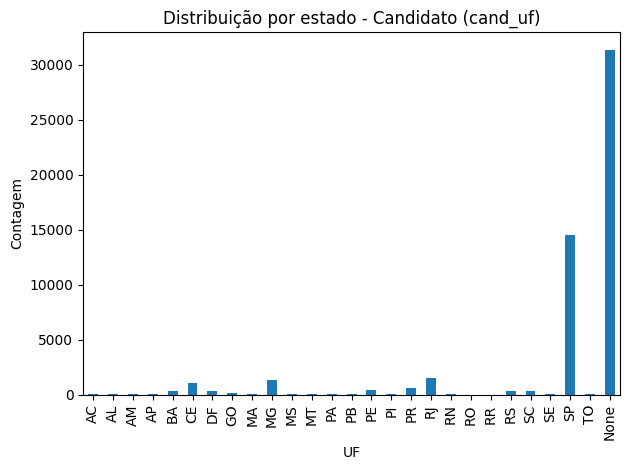

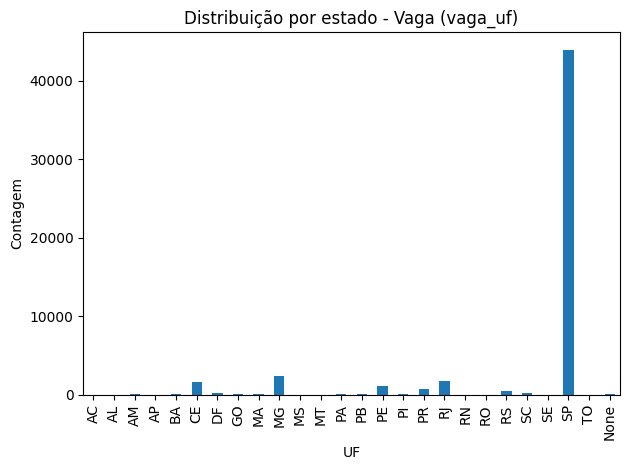

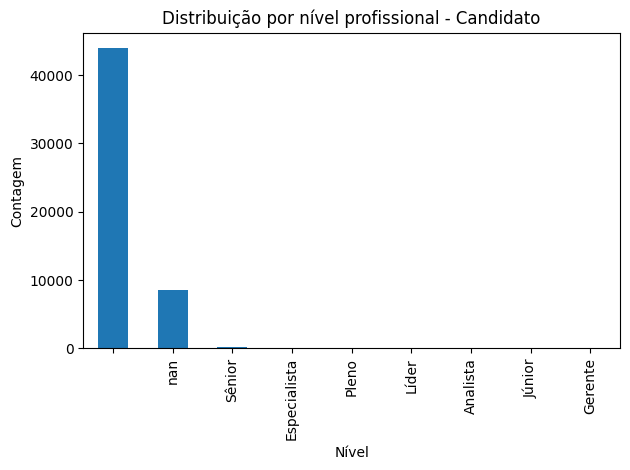

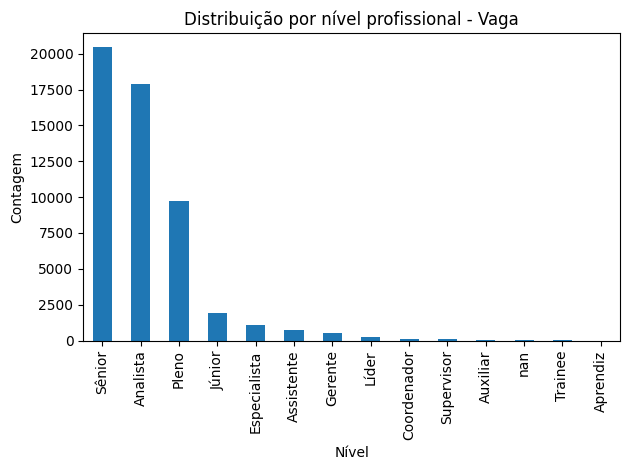

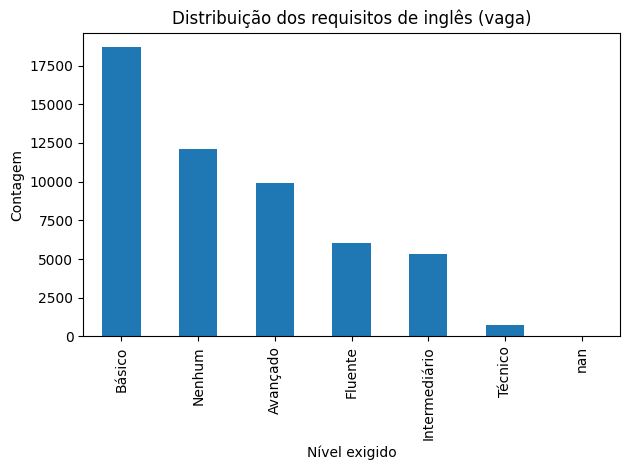

/var/folders/wn/mvtmggnj1dq_6nyv75p5xk_80000gn/T/ipykernel_19596/2312301134.py:57: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


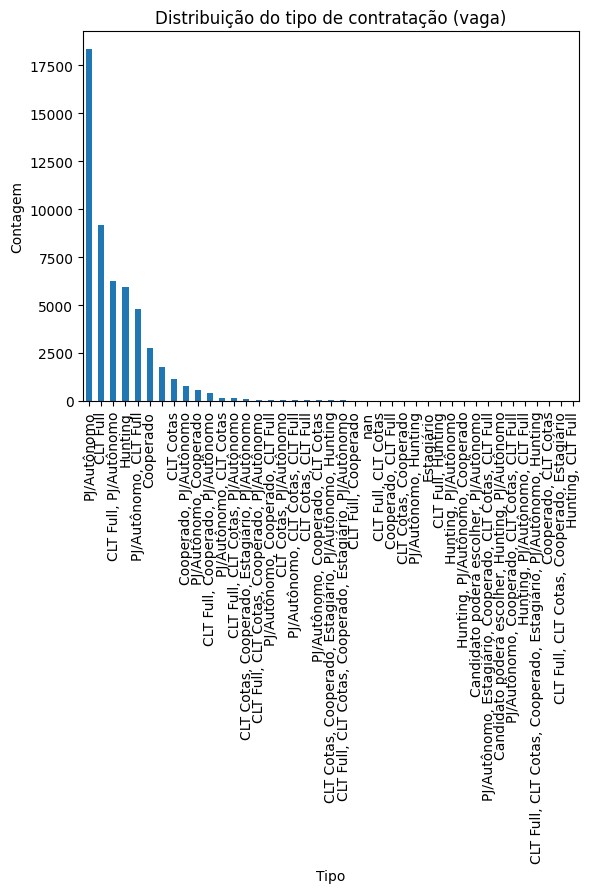

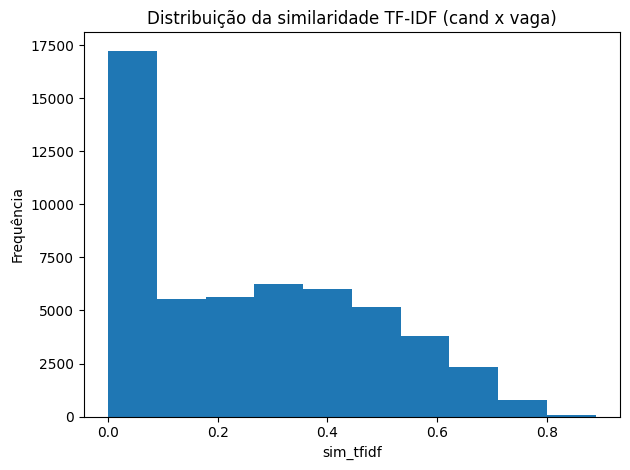

,same_state,taxa_label_1
0,False,0.179318
1,True,0.146559


In [23]:
# Análises pedidas e extras
# 1) Distribuição por estado - Candidato
plt.figure()
df_final["cand_uf"].value_counts(dropna=False).sort_index().plot(kind="bar")
plt.title("Distribuição por estado - Candidato (cand_uf)")
plt.xlabel("UF")
plt.ylabel("Contagem")
plt.tight_layout()
plt.show()

# 1b) Distribuição por estado - Vaga
plt.figure()
df_final["vaga_uf"].value_counts(dropna=False).sort_index().plot(kind="bar")
plt.title("Distribuição por estado - Vaga (vaga_uf)")
plt.xlabel("UF")
plt.ylabel("Contagem")
plt.tight_layout()
plt.show()

# 2) Distribuição por nível profissional
if "cand_informacoes_profissionais_nivel_profissional" in merged.columns:
    plt.figure()
    merged["cand_informacoes_profissionais_nivel_profissional"].astype(str).value_counts(dropna=False).plot(kind="bar")
    plt.title("Distribuição por nível profissional - Candidato")
    plt.xlabel("Nível")
    plt.ylabel("Contagem")
    plt.tight_layout()
    plt.show()

if "vaga_perfil_vaga_nivel_profissional" in merged.columns:
    plt.figure()
    merged["vaga_perfil_vaga_nivel_profissional"].astype(str).value_counts(dropna=False).plot(kind="bar")
    plt.title("Distribuição por nível profissional - Vaga")
    plt.xlabel("Nível")
    plt.ylabel("Contagem")
    plt.tight_layout()
    plt.show()

# 3) Requisitos de inglês (vaga)
if "vaga_perfil_vaga_nivel_ingles" in merged.columns:
    plt.figure()
    merged["vaga_perfil_vaga_nivel_ingles"].astype(str).value_counts(dropna=False).plot(kind="bar")
    plt.title("Distribuição dos requisitos de inglês (vaga)")
    plt.xlabel("Nível exigido")
    plt.ylabel("Contagem")
    plt.tight_layout()
    plt.show()

# 4) Tipo de contratação (vaga)
tipo_col = "vaga_informacoes_basicas_tipo_contratacao" if "vaga_informacoes_basicas_tipo_contratacao" in merged.columns else ("vaga_tipo_contratacao" if "vaga_tipo_contratacao" in merged.columns else None)
if tipo_col:
    plt.figure()
    merged[tipo_col].astype(str).value_counts(dropna=False).plot(kind="bar")
    plt.title("Distribuição do tipo de contratação (vaga)")
    plt.xlabel("Tipo")
    plt.ylabel("Contagem")
    plt.tight_layout()
    plt.show()

# 5) Extras: histograma TF-IDF e taxa de label=1 por same_state
if "sim_tfidf" in df_final.columns:
    plt.figure()
    df_final["sim_tfidf"].astype(float).plot(kind="hist", bins=10)
    plt.title("Distribuição da similaridade TF-IDF (cand x vaga)")
    plt.xlabel("sim_tfidf")
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

if {"same_state","label_contratado"}.issubset(df_final.columns):
    taxa = df_final.groupby("same_state")["label_contratado"].mean().rename("taxa_label_1").reset_index()
    display(taxa)


In [24]:
df_final[df_final.label_contratado.isna()]

,prop_nome,prop_codigo,prop_situacao_candidato,prop_vaga_id,prop_vaga_titulo,prop_vaga_modalidade,vaga_vaga_id,vaga_informacoes_basicas_data_requicisao,vaga_informacoes_basicas_titulo_vaga,vaga_informacoes_basicas_vaga_sap,...,vaga_is_PJ,vaga_is_Estagiario,vaga_is_Cotas,cand_is_Junior,cand_is_Pleno,cand_is_Senior,vaga_is_Junior,vaga_is_Pleno,vaga_is_Senior,label_contratado


In [25]:
print(df_final.label_contratado.value_counts())
df_final.label_contratado.value_counts(normalize=True)

label_contratado
0.0    43860
1.0     8961
Name: count, dtype: int64


label_contratado
0.0    0.830352
1.0    0.169648
Name: proportion, dtype: float64